### Stage 2: Contour Aperture Extraction\nWe use explicit % peak flux contours instead of geometric ellipses to isolate gas structures.

In [ ]:
import numpy as np
from astropy.io import fits
import sep
import matplotlib.pyplot as plt
from scipy.ndimage import label
from scipy.optimize import curve_fit
import os

os.makedirs('Contour_Output', exist_ok=True)

# 1. Load Data
s3d_file = '../NIRSpec_IFU/COS-87259_BGSUB_g395h-f290lp_s3d.fits'
s3d = fits.open(s3d_file)
hdr = s3d['sci'].header
f3d = s3d['sci'].data
e3d = s3d['err'].data
fnu_0 = hdr['pixar_sr']

# Wavelength array (unit: micron)
wl0, dwl, wl_len = hdr['CRVAL3'], hdr['CDELT3'], hdr['NAXIS3']
wl = wl0 + np.arange(wl_len) * dwl

# Build Rest-Frame Optical Stack
wl_det = ((wl>3.7515) & (wl<3.7601)) | ((wl>3.7707) & (wl<4.0274))
ivw_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)

nan_mask = np.isnan(ivw_stack)
ivw_stack[nan_mask] = np.nan
bkg = sep.Background(ivw_stack, mask=nan_mask, bw=5, bh=5)
det_thre = 2.5 * bkg.globalrms + bkg.back()

# Original anchor coordinates roughly targeting the clumps
anchors = {
    'Center': (28, 24),
    'West': (28, 24), # Approx center of West
    'North': (27, 28),
    'South': (26, 15),
    'Southeast': (19, 20)
}

# Find exact local peaks
peaks = {}
for name, (x_approx, y_approx) in anchors.items():
    # Search in a 6x6 box around anchor
    y_min, y_max = max(0, y_approx-3), min(ivw_stack.shape[0], y_approx+3)
    x_min, x_max = max(0, x_approx-3), min(ivw_stack.shape[1], x_approx+3)
    
    sub_map = ivw_stack[y_min:y_max, x_min:x_max]
    sub_map[np.isnan(sub_map)] = -np.inf
    max_idx = np.unravel_index(np.argmax(sub_map), sub_map.shape) #找到峰值处的索引
    
    peak_y = y_min + max_idx[0]
    peak_x = x_min + max_idx[1]
    peak_flux = ivw_stack[peak_y, peak_x]
    
    peaks[name] = {'y': peak_y, 'x': peak_x, 'flux': peak_flux}
    print(f"[{name}] Peak found at X={peak_x}, Y={peak_y} with Flux={peak_flux:.4f}")


[Center] Peak found at X=27, Y=23 with Flux=0.3801
[West] Peak found at X=27, Y=23 with Flux=0.3801
[North] Peak found at X=27, Y=27 with Flux=0.1762
[South] Peak found at X=27, Y=16 with Flux=0.1256
[Southeast] Peak found at X=18, Y=20 with Flux=0.0809


C:\Users\zhigu\AppData\Local\Temp\ipykernel_37212\2361134894.py:25: RuntimeWarning: Mean of empty slice
  ivw_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)


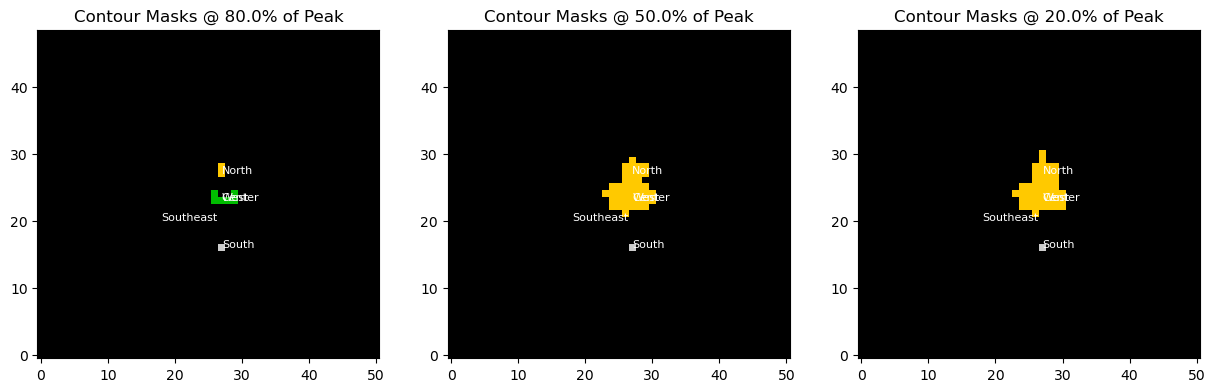

In [6]:
def get_clump_mask(clump_name, percentage_level):
    peak_info = peaks[clump_name]
    threshold = peak_info['flux'] * percentage_level
    
    # Must be above 3-sigma noise floor
    floor = bkg.back()[peak_info['y'], peak_info['x']] + 3*bkg.globalrms
    if threshold < floor:
        threshold = floor
        
    # Mask all pixels above threshold
    binary_mask = (ivw_stack >= threshold) & (~nan_mask)
    
    # Label disjoint regions
    labeled_array, num_features = label(binary_mask)
    
    # Find which region contains our peak
    peak_label = labeled_array[peak_info['y'], peak_info['x']]
    
    if peak_label == 0:
        # Peak was below threshold somehow, fallback
        return np.zeros_like(binary_mask, dtype=bool)
        
    final_mask = (labeled_array == peak_label)
    return final_mask

# Plot masks to visually inspect them!
fig, axs = plt.subplots(1, 3, figsize=(15,5))
levels = [0.8, 0.5, 0.2]

for i, lvl in enumerate(levels):
    master_mask = np.zeros_like(ivw_stack)
    for c_idx, c_name in enumerate(peaks.keys()):
        m = get_clump_mask(c_name, lvl)
        master_mask[m] = c_idx + 1 # Color code clumps
        
    axs[i].imshow(master_mask, origin='lower', cmap='nipy_spectral')
    axs[i].set_title(f"Contour Masks @ {lvl*100}% of Peak")
    for c_name, p in peaks.items():
        axs[i].text(p['x'], p['y'], c_name, color='white', fontsize=8)
plt.show()


In [7]:
# Extract 1D spectra for each contour level
for c_name in peaks.keys():
    for lvl in levels:
        mask = get_clump_mask(c_name, lvl)
        if not np.any(mask): continue
        
        f1d, e1d = np.zeros(wl_len), np.zeros(wl_len)
        for i in range(wl_len):
            f1d[i] = np.nansum(f3d[i][mask]) * fnu_0
            e1d[i] = np.sqrt(np.nansum((e3d[i][mask])**2)) * fnu_0
            
        f1d = f1d * 1e-17 * 3e18 / (wl * 1e4)**2
        e1d = e1d * 1e-17 * 3e18 / (wl * 1e4)**2
        
        np.savetxt(f'Contour_Output/{c_name}_Lvl{lvl}_spectrum.txt', np.column_stack((wl, f1d, e1d)), header='Wavelength_um Flux Err', comments='')
print("All level spectra saved to Contour_Output/")


All level spectra saved to Contour_Output/


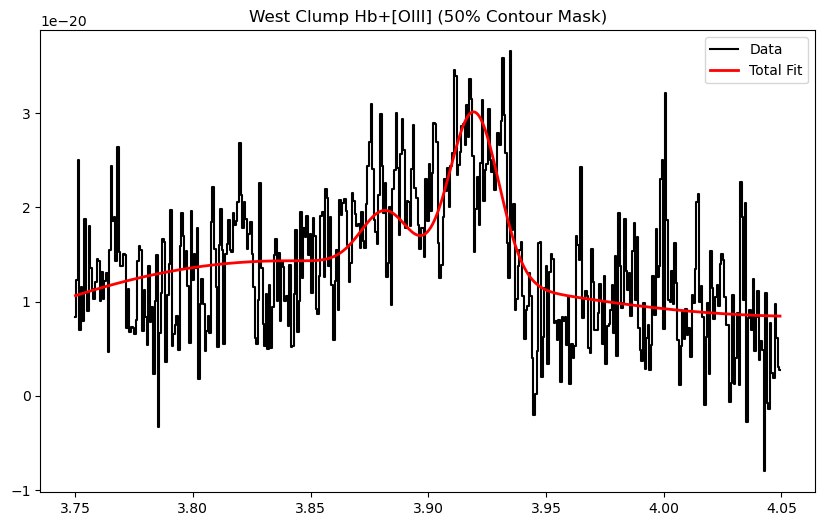

Narrow FWHM: 1884 km/s, Broad FWHM: 23550 km/s


In [9]:
# Fitting Logic (Adapted from fit_spectra.py)
c_kms = 299792.458
wl_rest = {'Hb': 4861.33, 'O4959': 4958.91, 'O5007': 5006.84, 'N6548': 6548.05, 'Ha': 6562.81, 'N6584': 6583.45}

def gaussian(x, amp, cen, sig): return amp * np.exp(-(x-cen)**2 / (2*sig**2))

def model_HBOIII(x, m, c, z, amp_Hb_n, amp_Hb_b, amp_O4959, sig_v_n, sig_v_b):
    cont = m * x + c
    Hb_n = gaussian(x, amp_Hb_n, wl_rest['Hb']*(1+z), wl_rest['Hb']*(1+z)*(sig_v_n/c_kms))
    Hb_b = gaussian(x, amp_Hb_b, wl_rest['Hb']*(1+z), wl_rest['Hb']*(1+z)*(sig_v_b/c_kms))
    O49 = gaussian(x, amp_O4959, wl_rest['O4959']*(1+z), wl_rest['O4959']*(1+z)*(sig_v_n/c_kms))
    O50 = gaussian(x, amp_O4959 * 2.98, wl_rest['O5007']*(1+z), wl_rest['O5007']*(1+z)*(sig_v_n/c_kms))
    return cont + Hb_n + Hb_b + O49 + O50

# Loop and fit the 50% contour for West clump as an example
w_data = np.loadtxt('Contour_Output/West_Lvl0.5_spectrum.txt', skiprows=1)
vmask = w_data[:, 1] > -1e-18
wl_obs = w_data[vmask, 0] * 10000 
flux = w_data[vmask, 1] * 1e19 

win_mask = (wl_obs > 37500) & (wl_obs < 40500)
w1, f1 = wl_obs[win_mask], flux[win_mask]

p0 = [0, np.median(f1), 6.85, 1.0, 1.0, 1.0, 200, 3000]
bounds_min = [-np.inf, -100, 6.80, 0, 0, 0, 10, 800]
bounds_max = [np.inf, 100, 6.90, np.inf, np.inf, np.inf, 800, 10000]

popt, _ = curve_fit(model_HBOIII, w1, f1, p0=p0, bounds=(bounds_min, bounds_max), maxfev=10000)

plt.figure(figsize=(10,6))
plt.plot(w1/10000, f1/1e19, 'k-', label='Data', ds='steps-mid')
plt.plot(w1/10000, model_HBOIII(w1, *popt)/1e19, 'r-', label='Total Fit', lw=2)
plt.title("West Clump Hb+[OIII] (50% Contour Mask)")
plt.legend()
plt.show()
print(f"Narrow FWHM: {popt[6]*2.355:.0f} km/s, Broad FWHM: {popt[7]*2.355:.0f} km/s")
